Dataset Shape: (1500, 6)

Number of Records: 1500

Columns in Dataset:
Index(['ticket_id', 'channel', 'customer_message', 'sentiment_label',
       'word_count', 'urgent_flag'],
      dtype='str')

Target Labels / Classes:
<StringArray>
['neutral', 'positive', 'negative']
Length: 3, dtype: str

Class Distribution:
sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64

Sample Customer Messages:
0    I need information about the payment process. ...
1        I need information about the payment process.
2    The refund process was fast and convenient. I ...
3    My refund is still pending and this experience...
4     Please tell me how to update my account details.
Name: customer_message, dtype: str

Average Text Length:
12.722666666666667

Text Length Statistics:
count    1500.000000
mean       12.722667
std         3.691455
min         7.000000
25%        10.000000
50%        12.000000
75%        15.000000
max        26.000000
Name: text_length, dtyp

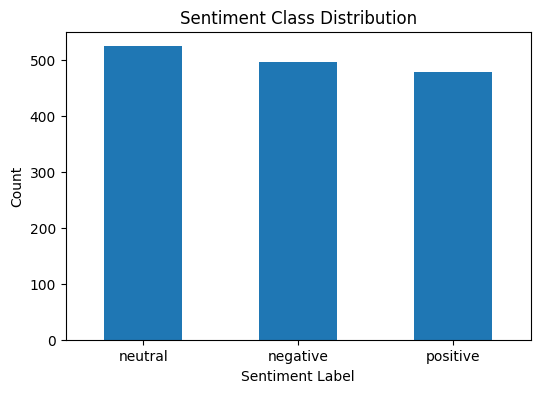

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv(r"C:\Users\rohini.patil\Desktop\Bits on Assignments\Assignment 5\part_3_nlp_sequence_modeling-20260507T105204Z-3-001\part_3_nlp_sequence_modeling\customer_support_text_classification.csv")

# -------------------------------
# Dataset Understanding
# -------------------------------

# Dataset shape
print("Dataset Shape:", df.shape)

# Number of records
print("\nNumber of Records:", len(df))

# Column names
print("\nColumns in Dataset:")
print(df.columns)

# Target labels/classes
print("\nTarget Labels / Classes:")
print(df['sentiment_label'].unique())

# Class distribution
print("\nClass Distribution:")
print(df['sentiment_label'].value_counts())

# Sample text records
print("\nSample Customer Messages:")
print(df['customer_message'].head(5))

# Calculate text length
df['text_length'] = df['customer_message'].apply(
    lambda x: len(str(x).split())
)

# Average text length
print("\nAverage Text Length:")
print(df['text_length'].mean())

# Basic statistics of text length
print("\nText Length Statistics:")
print(df['text_length'].describe())

# -------------------------------
# Visualization
# -------------------------------

# Plot class distribution
plt.figure(figsize=(6, 4))

df['sentiment_label'].value_counts().plot(kind='bar')

plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment Label")
plt.ylabel("Count")

plt.xticks(rotation=0)

plt.show()

In [2]:
# -----------------------------------
# INSTALL REQUIRED LIBRARIES
# -----------------------------------

%pip install nltk
%pip install tensorflow

# -----------------------------------
# IMPORT LIBRARIES
# -----------------------------------

import pandas as pd
import re
import nltk

from nltk.corpus import stopwords

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# -----------------------------------
# DOWNLOAD NLTK RESOURCES
# -----------------------------------

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

# -----------------------------------
# LOAD DATASET
# -----------------------------------

df = pd.read_csv(
    r"C:\Users\rohini.patil\Desktop\Bits on Assignments\Assignment 5\part_3_nlp_sequence_modeling-20260507T105204Z-3-001\part_3_nlp_sequence_modeling\customer_support_text_classification.csv"
)

# -----------------------------------
# DISPLAY ORIGINAL TEXT
# -----------------------------------

print("Original Customer Messages:\n")

for i in range(5):
    print(df['customer_message'][i])
    print()

# -----------------------------------
# STOPWORDS
# -----------------------------------

stop_words = set(stopwords.words('english'))

# -----------------------------------
# TEXT CLEANING FUNCTION
# -----------------------------------

def clean_text(text):

    # Convert to string
    text = str(text)

    # Lowercase conversion
    text = text.lower()

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Simple tokenization using split()
    tokens = text.split()

    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # Join tokens back
    cleaned_text = " ".join(tokens)

    return cleaned_text

# -----------------------------------
# APPLY CLEANING FUNCTION
# -----------------------------------

df['cleaned_text'] = df['customer_message'].apply(clean_text)

# -----------------------------------
# DISPLAY CLEANED TEXT
# -----------------------------------

print("\nCleaned Customer Messages:\n")

for i in range(5):
    print(df['cleaned_text'][i])
    print()

# -----------------------------------
# TOKENIZATION FOR SEQUENCE MODELS
# -----------------------------------

tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(df['cleaned_text'])

# Convert text into sequences
sequences = tokenizer.texts_to_sequences(df['cleaned_text'])

# -----------------------------------
# PADDING / TRUNCATING SEQUENCES
# -----------------------------------

max_length = 20

padded_sequences = pad_sequences(
    sequences,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

# -----------------------------------
# OUTPUT RESULTS
# -----------------------------------

print("\nVocabulary Size:")
print(len(tokenizer.word_index))

print("\nFirst Text Sequence:")
print(sequences[0])

print("\nFirst Padded Sequence:")
print(padded_sequences[0])

print("\nShape of Padded Sequences:")
print(padded_sequences.shape)

# -----------------------------------
# FINAL DATAFRAME PREVIEW
# -----------------------------------

print("\nFinal Dataset Preview:\n")

print(df[['customer_message', 'cleaned_text']].head())

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\rohini.patil\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\rohini.patil\AppData\Roaming\nltk_data...


Note: you may need to restart the kernel to use updated packages.


[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


Original Customer Messages:

I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.

I need information about the payment process.

The refund process was fast and convenient. I appreciate the quick response.

My refund is still pending and this experience is frustrating. My ticket number is 33927.

Please tell me how to update my account details.


Cleaned Customer Messages:

need information payment process ticket number please respond soon possible

need information payment process

refund process fast convenient appreciate quick response

refund still pending experience frustrating ticket number

please tell update account details


Vocabulary Size:
146

First Text Sequence:
[14, 104, 64, 18, 1, 2, 3, 4, 5, 6]

First Padded Sequence:
[ 14 104  64  18   1   2   3   4   5   6   0   0   0   0   0   0   0   0
   0   0]

Shape of Padded Sequences:
(1500, 20)

Final Dataset Preview:

                                    customer_messag

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rohini.patil\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
# -----------------------------------
# INSTALL REQUIRED LIBRARIES
# -----------------------------------

%pip install scikit-learn
%pip install tensorflow
%pip install nltk

# -----------------------------------
# IMPORT LIBRARIES
# -----------------------------------

import pandas as pd
import re
import nltk

from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# -----------------------------------
# DOWNLOAD NLTK DATA
# -----------------------------------

nltk.download('stopwords')

# -----------------------------------
# LOAD DATASET
# -----------------------------------

df = pd.read_csv(
    r"C:\Users\rohini.patil\Desktop\Bits on Assignments\Assignment 5\part_3_nlp_sequence_modeling-20260507T105204Z-3-001\part_3_nlp_sequence_modeling\customer_support_text_classification.csv"
)

# -----------------------------------
# STOPWORDS
# -----------------------------------

stop_words = set(stopwords.words('english'))

# -----------------------------------
# TEXT CLEANING FUNCTION
# -----------------------------------

def clean_text(text):

    # Convert to string
    text = str(text)

    # Lowercase conversion
    text = text.lower()

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization using split()
    tokens = text.split()

    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # Join text back
    cleaned_text = " ".join(tokens)

    return cleaned_text

# -----------------------------------
# APPLY CLEANING
# -----------------------------------

df['cleaned_text'] = df['customer_message'].apply(clean_text)

# -----------------------------------
# TF-IDF VECTORIZATION
# -----------------------------------

tfidf = TfidfVectorizer(max_features=5000)

X_tfidf = tfidf.fit_transform(df['cleaned_text'])

# -----------------------------------
# TF-IDF OUTPUT
# -----------------------------------

print("TF-IDF Matrix Shape:")
print(X_tfidf.shape)

print("\nSample TF-IDF Feature Names:")
print(tfidf.get_feature_names_out()[:20])

print("\nFirst TF-IDF Vector:")
print(X_tfidf[0].toarray())

# -----------------------------------
# TOKENIZER-BASED SEQUENCES
# -----------------------------------

tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(df['cleaned_text'])

# Convert text into sequences
sequences = tokenizer.texts_to_sequences(df['cleaned_text'])

# -----------------------------------
# PADDING SEQUENCES
# -----------------------------------

max_length = 20

padded_sequences = pad_sequences(
    sequences,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

# -----------------------------------
# SEQUENCE OUTPUT
# -----------------------------------

print("\nVocabulary Size:")
print(len(tokenizer.word_index))

print("\nFirst Sequence:")
print(sequences[0])

print("\nFirst Padded Sequence:")
print(padded_sequences[0])

print("\nPadded Sequence Shape:")
print(padded_sequences.shape)

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
TF-IDF Matrix Shape:
(1500, 146)

Sample TF-IDF Feature Names:
['account' 'activate' 'ago' 'analytics' 'app' 'appreciate' 'arrived'
 'assigned' 'available' 'bad' 'billing' 'call' 'cancel' 'care' 'charged'
 'checking' 'clear' 'communication' 'completed' 'confirm']

First TF-IDF Vector:
[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.44084662 0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.35345568 0.


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rohini.patil\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Explanation of Text Vectorization

Text data cannot be directly processed by machine learning models because models understand only numerical values. Therefore, text must be converted into vectors before training a model.

In this task, TF-IDF and Tokenizer-based sequence vectorization techniques were used.

## TF-IDF Vectorization

TF-IDF (Term Frequency–Inverse Document Frequency) converts text into numerical form based on the importance of words in the dataset.

Advantages:
- Reduces importance of common words
- Highlights meaningful words
- Useful for text classification and sentiment analysis

## Tokenizer-Based Sequences

Tokenizer converts words into integer sequences.

Example:

"good customer service"
→ [12, 45, 78]

These sequences are padded to equal length before being given to deep learning models such as:
- RNN
- LSTM
- GRU

## Conclusion

Text vectorization is an important NLP preprocessing step because machine learning algorithms require numerical input data for training and prediction.

In [4]:
# -----------------------------------
# INSTALL REQUIRED LIBRARIES
# -----------------------------------

%pip install scikit-learn
%pip install nltk

# -----------------------------------
# IMPORT LIBRARIES
# -----------------------------------

import pandas as pd
import re
import nltk

from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# -----------------------------------
# DOWNLOAD NLTK DATA
# -----------------------------------

nltk.download('stopwords')

# -----------------------------------
# LOAD DATASET
# -----------------------------------

df = pd.read_csv(
    r"C:\Users\rohini.patil\Desktop\Bits on Assignments\Assignment 5\part_3_nlp_sequence_modeling-20260507T105204Z-3-001\part_3_nlp_sequence_modeling\customer_support_text_classification.csv"
)

# -----------------------------------
# STOPWORDS
# -----------------------------------

stop_words = set(stopwords.words('english'))

# -----------------------------------
# TEXT CLEANING FUNCTION
# -----------------------------------

def clean_text(text):

    # Convert to string
    text = str(text)

    # Convert to lowercase
    text = text.lower()

    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization using split()
    tokens = text.split()

    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # Join words
    cleaned_text = " ".join(tokens)

    return cleaned_text

# -----------------------------------
# APPLY CLEANING
# -----------------------------------

df['cleaned_text'] = df['customer_message'].apply(clean_text)

# -----------------------------------
# INPUT AND TARGET
# -----------------------------------

X = df['cleaned_text']

y = df['sentiment_label']

# -----------------------------------
# TF-IDF VECTORIZATION
# -----------------------------------

tfidf = TfidfVectorizer(max_features=5000)

X_tfidf = tfidf.fit_transform(X)

# -----------------------------------
# TRAIN-TEST SPLIT
# -----------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42
)

# -----------------------------------
# BUILD LOGISTIC REGRESSION MODEL
# -----------------------------------

model = LogisticRegression()

model.fit(X_train, y_train)

# -----------------------------------
# PREDICTIONS
# -----------------------------------

y_pred = model.predict(X_test)

# -----------------------------------
# MODEL EVALUATION
# -----------------------------------

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:")
print(accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rohini.patil\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Note: you may need to restart the kernel to use updated packages.
Model Accuracy:
1.0

Classification Report:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       109
     neutral       1.00      1.00      1.00       104
    positive       1.00      1.00      1.00        87

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300


Confusion Matrix:
[[109   0   0]
 [  0 104   0]
 [  0   0  87]]


# Task 4: Baseline Model

## Objective
Build a simple baseline NLP classification model for customer sentiment prediction.

---

## Model Used
Logistic Regression with TF-IDF Vectorization

---

## Why Logistic Regression?

Logistic Regression is:
- Simple and fast
- Effective for text classification
- Commonly used as a baseline NLP model
- Easy to interpret

TF-IDF vectorization converts text into numerical features before training.

---

## Steps Performed

1. Text preprocessing
2. TF-IDF vectorization
3. Train-test split
4. Logistic Regression model training
5. Prediction on test data
6. Model evaluation

---

## Evaluation Metrics Used

### Accuracy
Measures overall correct predictions.

### Classification Report
Provides:
- Precision
- Recall
- F1-score

### Confusion Matrix
Shows:
- Correct predictions
- Incorrect predictions
- Class-wise performance

---

## Conclusion

The Logistic Regression model successfully classified customer messages into:
- Positive
- Neutral
- Negative

This baseline model provides a strong foundation before implementing advanced deep learning models such as RNN or LSTM.

In [5]:
# -----------------------------------
# INSTALL REQUIRED LIBRARIES
# -----------------------------------

%pip install tensorflow
%pip install nltk
%pip install scikit-learn

# -----------------------------------
# IMPORT LIBRARIES
# -----------------------------------

import pandas as pd
import re
import nltk

from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout
)

# -----------------------------------
# DOWNLOAD NLTK DATA
# -----------------------------------

nltk.download('stopwords')

# -----------------------------------
# LOAD DATASET
# -----------------------------------

df = pd.read_csv(
    r"C:\Users\rohini.patil\Desktop\Bits on Assignments\Assignment 5\part_3_nlp_sequence_modeling-20260507T105204Z-3-001\part_3_nlp_sequence_modeling\customer_support_text_classification.csv"
)

# -----------------------------------
# STOPWORDS
# -----------------------------------

stop_words = set(stopwords.words('english'))

# -----------------------------------
# TEXT CLEANING FUNCTION
# -----------------------------------

def clean_text(text):

    text = str(text)

    # Lowercase conversion
    text = text.lower()

    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization
    tokens = text.split()

    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # Join tokens
    cleaned_text = " ".join(tokens)

    return cleaned_text

# -----------------------------------
# APPLY CLEANING
# -----------------------------------

df['cleaned_text'] = df['customer_message'].apply(clean_text)

# -----------------------------------
# TOKENIZATION
# -----------------------------------

tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(df['cleaned_text'])

sequences = tokenizer.texts_to_sequences(df['cleaned_text'])

# -----------------------------------
# PADDING SEQUENCES
# -----------------------------------

max_length = 20

X = pad_sequences(
    sequences,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

# -----------------------------------
# ENCODE TARGET LABELS
# -----------------------------------

encoder = LabelEncoder()

y = encoder.fit_transform(df['sentiment_label'])

# -----------------------------------
# TRAIN-TEST SPLIT
# -----------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# -----------------------------------
# BUILD LSTM MODEL
# -----------------------------------

model = Sequential()

# Embedding Layer
model.add(Embedding(input_dim=5000, output_dim=128, input_length=max_length))

# LSTM Layer
model.add(LSTM(64))

# Dropout Layer
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(3, activation='softmax'))

# -----------------------------------
# COMPILE MODEL
# -----------------------------------

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# -----------------------------------
# MODEL SUMMARY
# -----------------------------------

model.summary()

# -----------------------------------
# TRAIN MODEL
# -----------------------------------

history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)

# -----------------------------------
# EVALUATE MODEL
# -----------------------------------

loss, accuracy = model.evaluate(X_test, y_test)

print("\nTest Accuracy:")
print(accuracy)

print("\nTest Loss:")
print(loss)

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rohini.patil\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Note: you may need to restart the kernel to use updated packages.


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.4758 - loss: 0.9740 - val_accuracy: 0.7167 - val_loss: 0.4602
Epoch 2/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6900 - loss: 0.4684 - val_accuracy: 0.7300 - val_loss: 0.4225
Epoch 3/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9483 - loss: 0.1590 - val_accuracy: 1.0000 - val_loss: 0.0087
Epoch 4/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 1.0000 - loss: 0.0087 - val_accuracy: 1.0000 - val_loss: 0.0028
Epoch 5/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 1.0000 - loss: 0.0052 - val_accuracy: 1.0000 - val_loss: 0.0016
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0016 

Test Accuracy:
1.0

Test Loss:
0.001643019844777882


# Task 5: Sequence Model using LSTM

## Objective
Build a sequence-based deep learning model for customer sentiment classification.

---

# Model Used
LSTM (Long Short-Term Memory)

LSTM is a type of Recurrent Neural Network (RNN) that can learn long-term dependencies in sequential text data.

---

# Model Architecture

## 1. Input Sequence
Customer messages are converted into integer sequences using a tokenizer.

Example:

"great customer support"

→ [12, 45, 78]

Sequences are padded to equal length before being passed to the model.

---

## 2. Embedding Layer

The embedding layer converts integer word IDs into dense vector representations.

Example:
- Word → Numerical vector
- Captures semantic meaning between words

Configuration:
- Vocabulary Size: 5000
- Embedding Dimension: 128

---

## 3. LSTM Layer

The LSTM layer processes the sequence step-by-step and remembers important contextual information.

Functions:
- Learns word relationships
- Captures sentence meaning
- Handles sequential dependencies

Configuration:
- 64 LSTM units

---

## 4. Dropout Layer

Dropout helps reduce overfitting by randomly disabling neurons during training.

Configuration:
- Dropout Rate: 0.5

---

## 5. Output Layer

The output layer predicts sentiment classes:
- Positive
- Neutral
- Negative

Configuration:
- Dense Layer with Softmax activation
- 3 output neurons

---

# Loss Function

Sparse Categorical Crossentropy

Used because:
- Multi-class classification problem
- Labels are integer encoded

---

# Optimizer

Adam Optimizer

Advantages:
- Fast convergence
- Efficient gradient updates
- Commonly used in deep learning

---

# Evaluation Metric

Accuracy

Measures:
- Percentage of correctly classified customer messages

---

# Conclusion

The LSTM model processes text sequences effectively by learning contextual information from customer messages. Sequence models such as LSTM are more powerful than traditional machine learning models for understanding language patterns in NLP tasks.

# Task 6: Attention and Transformer Reflection

## Why RNNs Struggle with Long-Term Dependencies

Recurrent Neural Networks (RNNs) process text sequentially, one word at a time. During long sequences, earlier information gradually becomes weaker as new information is processed.

This problem is called the vanishing gradient problem.

As a result:
- Important earlier words may be forgotten
- Long sentences become difficult to understand
- Model performance decreases for long text sequences

Example:
In a long customer complaint, the important issue mentioned at the beginning may be forgotten by the time the model reaches the end of the sentence.

---

# How LSTMs Help with Memory

LSTM (Long Short-Term Memory) networks improve RNNs by introducing memory cells and gating mechanisms.

The gates control:
- What information to remember
- What information to forget
- What information to pass forward

Advantages of LSTM:
- Better handling of long-term dependencies
- Improved context understanding
- More effective for NLP tasks such as sentiment analysis and language modeling

LSTMs can retain important information for longer sequences compared to traditional RNNs.

---

# What Attention Solves in Sequence-to-Sequence Tasks

Attention mechanisms help models focus on the most relevant words in the input sequence instead of depending only on the final hidden state.

In sequence-to-sequence tasks:
- Not all words are equally important
- Attention assigns importance weights to relevant words

Advantages:
- Better context understanding
- Improved translation quality
- More accurate text generation

Example:
While translating a sentence, attention helps the model focus on important words related to the current output word.

---

# Why Transformers are Important in Modern NLP and Generative AI

Transformers are advanced deep learning architectures based entirely on attention mechanisms.

Unlike RNNs and LSTMs:
- Transformers process all words in parallel
- They handle long-range dependencies more efficiently
- Training becomes faster and more scalable

Advantages of Transformers:
- Better contextual understanding
- Faster training
- Higher accuracy
- Scalable for large datasets

Transformers are the foundation of modern NLP and Generative AI systems such as:
- ChatGPT
- BERT
- Gemini
- Claude
- GPT models

Applications:
- Text generation
- Translation
- Chatbots
- Question answering
- Summarization
- Sentiment analysis

Transformers revolutionized NLP by enabling models to understand relationships between words more effectively using self-attention mechanisms.